In [142]:
import pandas as pd

In [143]:
df=pd.read_csv("/kaggle/input/datasets/justsimply/cardekho/cardekho_dataset.csv")

In [144]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [145]:
df.shape

(15411, 14)

In [146]:
df.describe

<bound method NDFrame.describe of        Unnamed: 0         car_name     brand     model  vehicle_age  \
0               0      Maruti Alto    Maruti      Alto            9   
1               1    Hyundai Grand   Hyundai     Grand            5   
2               2      Hyundai i20   Hyundai       i20           11   
3               3      Maruti Alto    Maruti      Alto            9   
4               4    Ford Ecosport      Ford  Ecosport            6   
...           ...              ...       ...       ...          ...   
15406       19537      Hyundai i10   Hyundai       i10            9   
15407       19540    Maruti Ertiga    Maruti    Ertiga            2   
15408       19541      Skoda Rapid     Skoda     Rapid            6   
15409       19542  Mahindra XUV500  Mahindra    XUV500            5   
15410       19543       Honda City     Honda      City            2   

       km_driven seller_type fuel_type transmission_type  mileage  engine  \
0         120000  Individual    Petr

In [147]:
nul=df.isnull()
nul.sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [176]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, 
    TargetEncoder, 
    RobustScaler, 
    FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

In [149]:
def compute_annual_usage(df_input):
    df_out = df_input.copy()
    adjusted_age = df_out['vehicle_age'].clip(lower=1)
    df_out['annual_usage_rate'] = df_out['km_driven'] / adjusted_age
    return df_out

usage_transformer = FunctionTransformer(compute_annual_usage, validate=False)

In [150]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [151]:
drop_feature=["car_name"]
df.drop(columns=drop_feature,inplace=True)

In [152]:
df.head()

,Unnamed: 0,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [153]:
df.shape

(15411, 13)

In [154]:
df["fuel_type"].unique()

array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object)

In [155]:
df["transmission_type"].unique()

array(['Manual', 'Automatic'], dtype=object)

<Axes: xlabel='km_driven'>

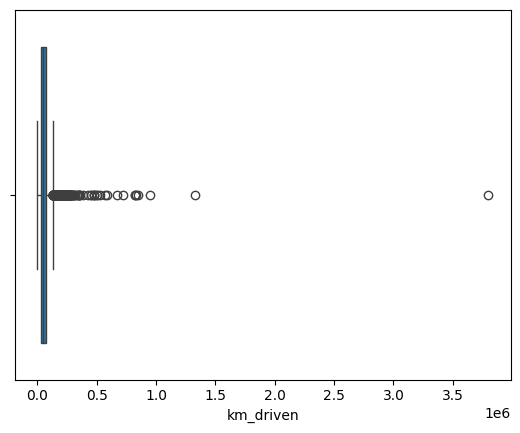

In [156]:
import seaborn as sns
sns.boxplot(x=df["km_driven"])

In [157]:
df = df[df["km_driven"] <= 950000]   

In [158]:
df.head()

,Unnamed: 0,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


<Axes: xlabel='mileage'>

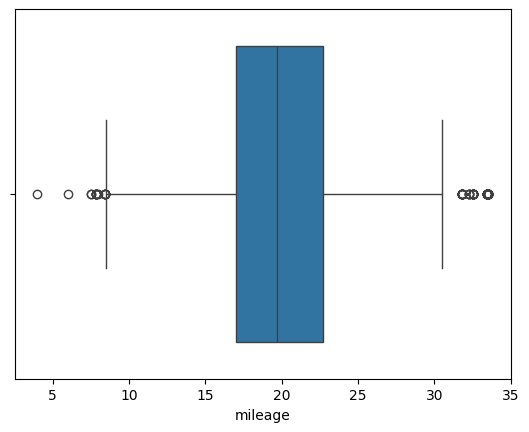

In [159]:
sns.boxplot(x=df["mileage"])

In [160]:
df.drop(columns=["Unnamed: 0"],inplace=True)

/tmp/ipykernel_58/439628513.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["Unnamed: 0"],inplace=True)


In [161]:
df

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...
15405,Hyundai,Grand,5,9229,Dealer,Petrol,Manual,18.90,1197,82.00,5,545000
15406,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000


In [162]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

In [163]:
numerical_features=['vehicle_age', 
    'km_driven', 
    'annual_usage_rate', 
    'mileage', 
    'engine', 
    'max_power', 
    'seats']

In [164]:
catagorical_features=[]

In [165]:
df["model"].unique

<bound method Series.unique of 0            Alto
1           Grand
2             i20
3            Alto
4        Ecosport
           ...   
15405       Grand
15406         i10
15407      Ertiga
15408       Rapid
15410        City
Name: model, Length: 15409, dtype: object>

In [166]:
df[numerical_features].skew()                   

KeyError: "['annual_usage_rate'] not in index"

In [ ]:
skewed_num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', RobustScaler())
])

In [ ]:
regular_num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

In [ ]:
low_cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
high_cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_enc', TargetEncoder(smooth="auto", cv=5))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('skewed_num', skewed_num_pipeline, ['km_driven', 'annual_usage_rate']),
        ('regular_num', regular_num_pipeline, ['vehicle_age', 'mileage', 'engine', 'max_power', 'seats']),
        ('low_cat', low_cat_pipeline, ['brand', 'seller_type', 'fuel_type', 'transmission_type']),
        ('high_cat', high_cat_pipeline, ['model'])
    ]
)

In [177]:
full_pipeline = Pipeline(steps=[
    ('feature_engineer', usage_transformer),
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [178]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [179]:
X_train.shape

(12327, 11)

In [180]:
y_test.shape

(3082,)

In [181]:
X_train

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
1347,Tata,Tiago,2,10000,Individual,Petrol,Manual,23.84,1199,84.00,5
13147,Renault,Triber,1,4500,Individual,Petrol,Manual,20.00,999,71.00,7
316,Honda,City,7,63000,Dealer,Petrol,Manual,17.80,1497,117.30,5
15354,Maruti,Celerio,4,50000,Individual,Petrol,Manual,23.10,998,67.04,5
4269,Maruti,Swift Dzire,3,32000,Individual,Diesel,Manual,28.40,1248,74.02,5
...,...,...,...,...,...,...,...,...,...,...,...
5191,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248,88.80,7
13419,Hyundai,Creta,6,70000,Individual,Diesel,Manual,21.38,1396,88.70,5
5390,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998,67.04,5
860,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.60,1197,81.86,5


In [183]:
y = df['selling_price']

In [184]:
y_test

14005     625000
14434     880000
10389    1250000
10962     720000
3105      435000
          ...   
15263     750000
6942      205000
9459     2200000
12761     250000
11209    6950000
Name: selling_price, Length: 3082, dtype: int64

In [185]:
print("Training the pipeline...")
full_pipeline.fit(X_train, y_train)

Training the pipeline...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Pipeline(steps=[('feature_engineer',
                 FunctionTransformer(func=<function compute_annual_usage at 0x7b5ad5a01a80>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('skewed_num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['km_driven',
                                                   'annual_usage_rate']),
                                                 ('reg...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['brand', 'seller_type',
                                                   'fuel_type',
                                                   'transmission_type']),
                                                 ('high_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target_enc',
                                                                   TargetEncoder())]),
                                                  ['model'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [186]:
train_r2 = full_pipeline.score(X_train, y_train)
test_r2 = full_pipeline.score(X_test, y_test)

In [187]:
print(f"Training R² Score: {train_r2:.3f}")
print(f"Testing R² Score:  {test_r2:.3f}")

Training R² Score: 0.931
Testing R² Score:  0.942


In [191]:
import pickle   
model_filename = 'car_valuation_model.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(full_pipeline, f)